# SHAP vs LIME Comparison — Chapter 4 Figure

Creates a side-by-side comparison of SHAP and LIME attributions for the same test instance (XGBoost).
Data is loaded from the stored experiment results (Paper 1 and Paper 2).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_DIR = Path('../../Thesis_latex/figures/figures_ch4')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load SHAP and LIME data for the same instance

In [2]:
# --- SHAP: from zero_shot.csv (stored in experiment results) ---
nle_df = pd.read_csv(
    '/home/fabian/Desktop/Second_XAI_Paper/Code/from_XAI_trustlab/explanations/zero_shot.csv'
)
shap_rows = nle_df[(nle_df['Model'] == 'XGB') & (nle_df['XAI'] == 'shap')]

# Use RowPos=4 (test instance index 4 = absolute row 144, week of 2009-11-09)
shap_row = shap_rows[shap_rows['RowPos'] == 4].iloc[0]
shap_vals = json.loads(shap_row['XAI_vals'].replace("'", '"'))
shap_base = float(shap_row['XAI_base_value'])
feature_vals = json.loads(shap_row['Feature_vals'].replace("'", '"'))

print(f'Instance: RowPos=4, week ending {shap_row["WeekEndDate"]}')
print(f'Prediction: {shap_row["Prediction"]:.2f}, True: {shap_row["TrueValue"]:.2f}')
print(f'SHAP base value: {shap_base:.2f}')
print(f'SHAP values: {shap_vals}')

Instance: RowPos=4, week ending 2009-11-09
Prediction: 175.44, True: 208.20
SHAP base value: 177.37
SHAP values: {'lag_1': -11.753593444824219, 'lag_2': 3.363478183746338, 'lag_3': -0.2629542350769043, 'lag_4': -2.308396339416504, 'lag_5': 1.7709486484527588, 'lag_6': -13.500605583190918, 'lag_7': -3.2460031509399414, 'weekofyear': 24.032060623168945, 'holiday_week_count': -0.018938304856419563}


In [3]:
# --- LIME: from stored LIME contributions ---
lime_df = pd.read_csv(
    '/home/fabian/Desktop/Second_XAI_Paper/Code/from_XAI_trustlab/xai/LIME_full_contributions_tight.csv'
)
# Row 144 = absolute index (test start at 140, so test index 4 = row 144)
lime_row = lime_df[(lime_df['Model'] == 'XGB') & (lime_df['Row'] == 144)].iloc[0]

features = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
            'weekofyear', 'holiday_week_count']
lime_vals = {f: lime_row[f] for f in features}
lime_intercept = lime_row['intercept']

print(f'LIME intercept: {lime_intercept:.2f}')
print(f'LIME values: {lime_vals}')

LIME intercept: 168.35
LIME values: {'lag_1': np.float64(20.577108089606064), 'lag_2': np.float64(-1.4232878292394804), 'lag_3': np.float64(3.918488418373446), 'lag_4': np.float64(1.018320385483508), 'lag_5': np.float64(-1.8004242306598128), 'lag_6': np.float64(5.186518054411084), 'lag_7': np.float64(-0.8258373003783437), 'weekofyear': np.float64(14.335251054094028), 'holiday_week_count': np.float64(0.0337151657056455)}


## 2. Create side-by-side comparison figure

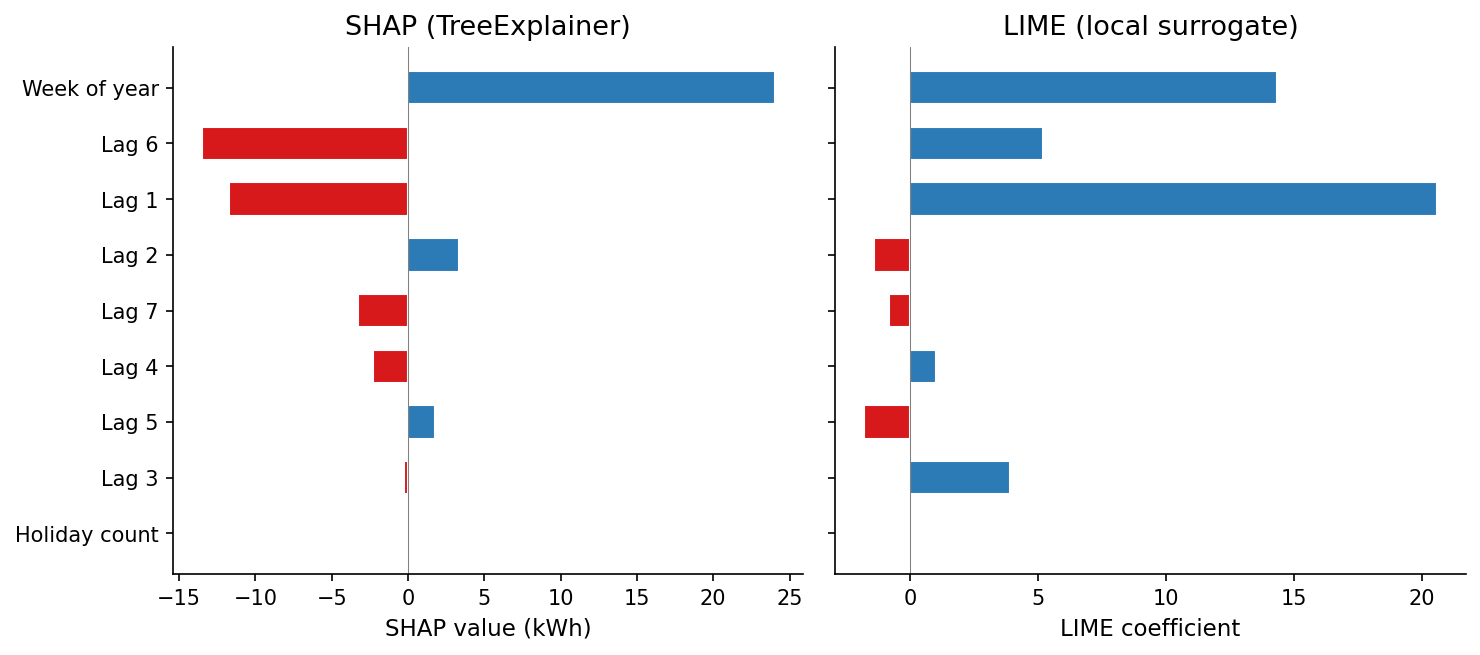

In [4]:
# Sort features by absolute SHAP value (descending)
sorted_features = sorted(features, key=lambda f: abs(shap_vals[f]), reverse=True)

shap_sorted = [shap_vals[f] for f in sorted_features]
lime_sorted = [lime_vals[f] for f in sorted_features]

# Pretty feature labels
label_map = {
    'lag_1': 'Lag 1', 'lag_2': 'Lag 2', 'lag_3': 'Lag 3', 'lag_4': 'Lag 4',
    'lag_5': 'Lag 5', 'lag_6': 'Lag 6', 'lag_7': 'Lag 7',
    'weekofyear': 'Week of year', 'holiday_week_count': 'Holiday count'
}

y_pos = np.arange(len(sorted_features))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

# SHAP
colors_shap = ['#d7191c' if v < 0 else '#2c7bb6' for v in shap_sorted]
ax1.barh(y_pos, shap_sorted, color=colors_shap, edgecolor='white', height=0.6)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([label_map[f] for f in sorted_features])
ax1.set_xlabel('SHAP value (kWh)')
ax1.set_title('SHAP (TreeExplainer)')
ax1.axvline(0, color='grey', linewidth=0.5)
ax1.invert_yaxis()

# LIME
colors_lime = ['#d7191c' if v < 0 else '#2c7bb6' for v in lime_sorted]
ax2.barh(y_pos, lime_sorted, color=colors_lime, edgecolor='white', height=0.6)
ax2.set_xlabel('LIME coefficient')
ax2.set_title('LIME (local surrogate)')
ax2.axvline(0, color='grey', linewidth=0.5)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_shap_vs_lime.pdf', bbox_inches='tight')
plt.show()